## Is the NVS distribution Boltzmann for the RWA oscillators?

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial
from jax.scipy.special import logsumexp
from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------

# System Physical Parameters
M = 1.0                # Mass (arbitrary units)
w_0 = 10.
damping = 0.0001
Qual = w_0/(2*damping)# Natural frequency (rad/s)
print(f"Qual: {Qual}")
gamma = 1000.         # Nonlinearity coefficient (Duffing term)

# Driving Forces Parameters
w_p = 2*w_0          # Parametric driving frequency (rad/s), set to 2*w_0 for parametric resonance
F_p = 5.          # Amplitude of parametric driving
F = 0.00              # Amplitude of direct driving
w_F = w_0            # Frequency of direct driving (rad/s)

# Thermal Parameters
k_B = 1.0            # Boltzmann's constant (arbitrary units)
T = .05            # Temperature (K) - currently set to 0

# Time and Simulation Parameters
period = 2*jnp.pi/w_0        # Natural period of oscillation
t0 = 0.0                     # Start time
num_periods = 1000000            # Number of periods to simulate
t1 = num_periods*period      # End time
dt0 = period/100           # Initial time step
num_pts_per_period = 100    # Number of points per period
ts_dim = jnp.linspace(t0, t1, num_periods*num_pts_per_period)



CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


Qual: 50000.0


In [3]:
def Hamiltonian(Q, P):
    dw = w_p/2 - w_0
    return 3*gamma/(16*w_p) * (Q**2 + P**2)**2 + dw/2 *(Q**2 - P**2) +  F_p/(4*M*w_p) * (P**2 - Q**2) - F*Q/(2*M*w_p)

temp_rescaling_factor = 1/2
def Hamiltonian_BM(Q, P):
    return Hamiltonian(Q, P)/(k_B * T*temp_rescaling_factor/(M*(w_0)**2))

def make_normalized_distribution(Qs, Ps):
    # Create a 2D mesh of all (x,y) points
    Qs, Ps = jnp.meshgrid(Qs, Ps)  # shape = (len(xs), len(ys))

    # Compute the log of unnormalized probabilities on the 2D grid
    log_unnorm_grid = -Hamiltonian_BM(Qs, Ps)  # shape = (len(xs), len(ys))

    # Flatten to compute log-sum-exp across all grid points
    log_unnorm_flat = log_unnorm_grid.ravel()  
    logZ = logsumexp(log_unnorm_flat)

    def BM_distribution(Q,P):
        return jnp.exp(-Hamiltonian_BM(Q, P) - logZ)

    return BM_distribution

Q_range = jnp.linspace(-5, 5, 100)/35
P_range = jnp.linspace(-5, 5, 100)/35

BM_distribution = make_normalized_distribution(Q_range,P_range)

BM_distribution_values = jax.vmap(jax.vmap(BM_distribution, in_axes=(None, 0)), in_axes=(0, None))(Q_range, P_range).T
BM_distribution_values_Q_marginal = jnp.sum(BM_distribution_values, axis=0)
BM_distribution_values_P_marginal = jnp.sum(BM_distribution_values, axis=1)
H_values = jax.vmap(jax.vmap(Hamiltonian, in_axes=(None, 0)), in_axes=(0, None))(Q_range, P_range).T

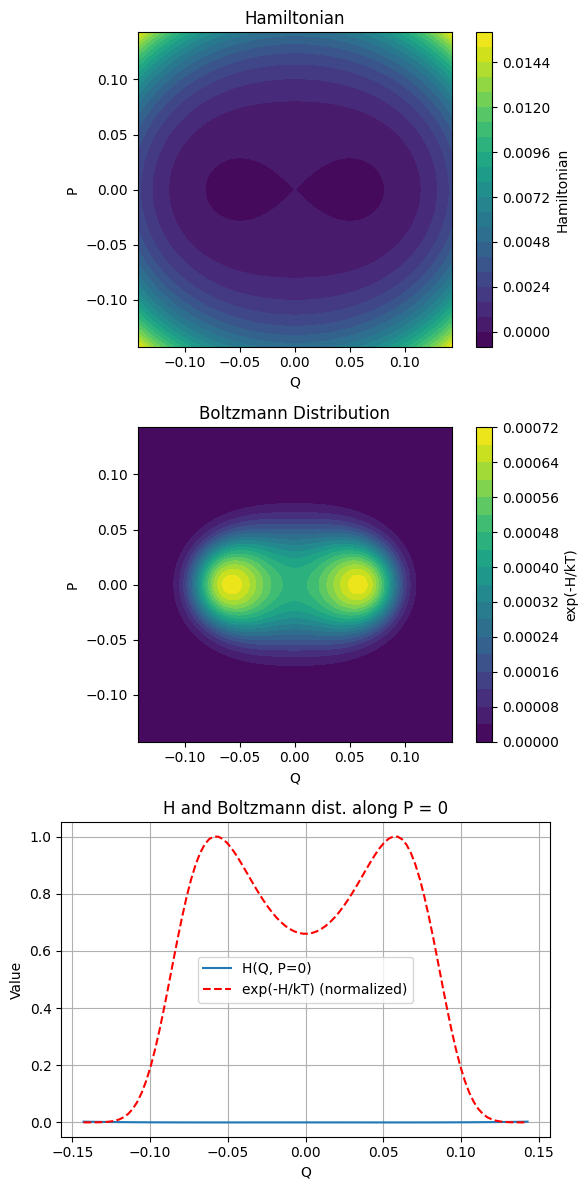

In [4]:
# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 12))

# Create Hamiltonian contour plot
contour1 = ax1.contourf(Q_range, P_range, H_values, levels=20, cmap='viridis')
plt.colorbar(contour1, ax=ax1, label='Hamiltonian')
ax1.set_aspect('equal')
ax1.set_xlabel('Q')
ax1.set_ylabel('P')
ax1.set_title('Hamiltonian')

# Create Boltzmann distribution contour plot
contour2 = ax2.contourf(Q_range, P_range, BM_distribution_values, levels=20, cmap='viridis')
plt.colorbar(contour2, ax=ax2, label='exp(-H/kT)')
ax2.set_aspect('equal')
ax2.set_xlabel('Q')
ax2.set_ylabel('P')
ax2.set_title('Boltzmann Distribution')

# Plot P = 0 line for both
H_P0 = jnp.array([Hamiltonian(q, 0.) for q in Q_range])
boltz_P0 = jnp.exp(-H_P0/(k_B * T*temp_rescaling_factor/(M*(w_0)**2)))

ax3.plot(Q_range, H_P0, label='H(Q, P=0)')
ax3.plot(Q_range, boltz_P0/jnp.max(boltz_P0), '--', label='exp(-H/kT) (normalized)', color='red')
ax3.set_xlabel('Q')
ax3.set_ylabel('Value')
ax3.set_title('H and Boltzmann dist. along P = 0')
ax3.grid(True)
ax3.legend()

plt.tight_layout()
plt.show()

In [5]:
# # Amplitude Equations SDEs for RWA
def drift_QP_fn(t, state, args):
    """
    Drift function 
    """
    Q, P = state
        
    H = lambda _Q, _P: Hamiltonian(_Q, _P)
    
    dQdt =  jax.grad(H, 1)(Q, P) - w_0/(2*Qual)*Q
    dPdt = -jax.grad(H, 0)(Q, P) - w_0/(2*Qual)*P
    
    # Drift terms
    return jnp.array([dQdt, dPdt])



def diffusion_QP_fn(t, state, args):
    """
    Diffusion matrix for Q and P equations.
    Returns a 2x2 matrix where diagonal terms represent independent noise for Q and P.
    """
    noise_strength_QP =  jnp.sqrt(2*(w_0/(2*Qual))*k_B * T/(M*w_0**2))  
    return noise_strength_QP * jnp.eye(2) 



In [6]:

w_shape = (2,)  # state is (Q, P)
brownian_motion_QP = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-3, w_shape, jr.PRNGKey(12), diffrax.SpaceTimeLevyArea
)

y0_QP = jnp.array([0., 0.0])

terms_QP = MultiTerm(ODETerm(drift_QP_fn), ControlTerm(diffusion_QP_fn, brownian_motion_QP))

saveat = diffrax.SaveAt(ts=ts_dim)

solution_QP = diffrax.diffeqsolve(
    terms_QP,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_QP,
    args=(),
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=1000000000000,
    stepsize_controller=diffrax.PIDController(rtol=1e-4, atol=1e-6),  # Enable adaptive stepping
)




/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

In [7]:
# Calculate decoherence time and use it for thinning
tau = 2 * Qual / w_0  # decoherence time
num_decoherence_times = (t1-t0)/tau
samples_per_tau = int(len(solution_QP.ys)/num_decoherence_times)  # number of samples per decoherence time

# Thin the samples by taking every samples_per_tau-th sample
sde_samples_QP = solution_QP.ys[::1]


In [8]:
sde_samples_QP.shape[0]


100000000

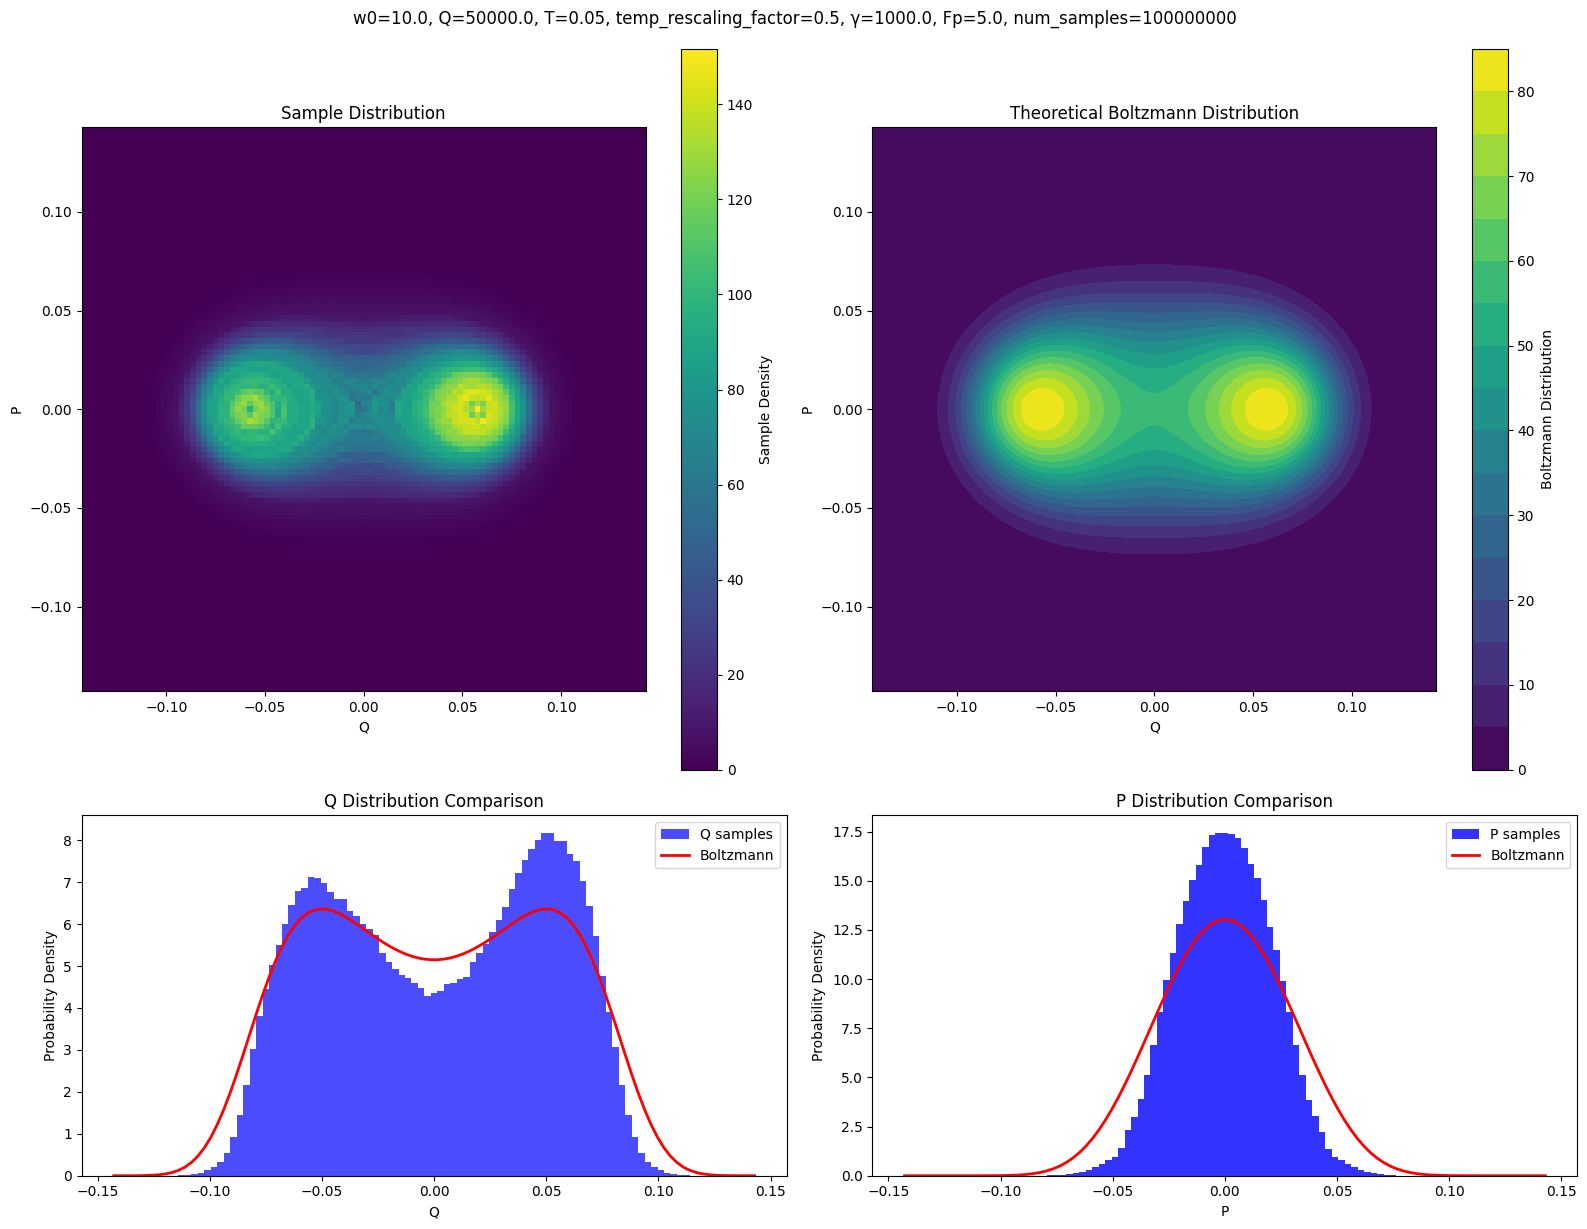

In [9]:
dQ = Q_range[1] - Q_range[0]
dP = P_range[1] - P_range[0]

# Create figure with a grid of subplots
fig = plt.figure(figsize=(16, 12))
gs = plt.GridSpec(2, 2, height_ratios=[2, 1])

# Top left: Phase space density plot of samples
ax1 = fig.add_subplot(gs[0, 0])
h = ax1.hist2d(sde_samples_QP[:, 0], sde_samples_QP[:, 1], 
               bins=[Q_range, P_range],  # Use Q_range and P_range for binning
               density=True,
               range=[[Q_range[0], Q_range[-1]], [P_range[0], P_range[-1]]])  # Set range explicitly
plt.colorbar(h[3], ax=ax1, label='Sample Density')
ax1.set_aspect('equal')
ax1.set_xlabel('Q')
ax1.set_ylabel('P')
ax1.set_title('Sample Distribution')

# Top right: Theoretical Boltzmann distribution
ax2 = fig.add_subplot(gs[0, 1])
contour = ax2.contourf(Q_range, P_range, BM_distribution_values/dQ/dP, 
                      levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax2, label='Boltzmann Distribution')
ax2.set_aspect('equal')
ax2.set_xlabel('Q')
ax2.set_ylabel('P')
ax2.set_title('Theoretical Boltzmann Distribution')

# Bottom: Comparison of marginal distributions
# Q distribution
ax3 = fig.add_subplot(gs[1, 0])
# Histogram of samples using the same range as theoretical distribution
ax3.hist(sde_samples_QP[:, 0], bins=Q_range, density=True, alpha=0.7, 
         label='Q samples', color='blue', range=(Q_range[0], Q_range[-1]))
# Theoretical marginal distribution
ax3.plot(Q_range, BM_distribution_values_Q_marginal/dQ, 'r-', label='Boltzmann', linewidth=2)
ax3.set_xlabel('Q')
ax3.set_ylabel('Probability Density')
ax3.set_title('Q Distribution Comparison')
ax3.legend()

# P distribution
ax4 = fig.add_subplot(gs[1, 1])
# Histogram of samples using the same range as theoretical distribution
ax4.hist(sde_samples_QP[:, 1], bins=P_range, density=True, alpha=0.8, 
         label='P samples', color='blue', range=(P_range[0], P_range[-1]))
# Theoretical marginal distribution
ax4.plot(P_range, BM_distribution_values_P_marginal/dP, 'r-', label='Boltzmann', linewidth=2)
ax4.set_xlabel('P')
ax4.set_ylabel('Probability Density')
ax4.set_title('P Distribution Comparison')
ax4.legend()


plt.tight_layout()
# Add title with parameters
title = f'w0={w_0}, Q={Qual}, T={T}, temp_rescaling_factor={temp_rescaling_factor}, γ={gamma}, Fp={F_p}, num_samples={sde_samples_QP.shape[0]}'
plt.suptitle(title, y=1.02)


import os

# Create the directory if it doesn't exist
save_dir = "../out/UnderstandingDistribution_thinned/"
os.makedirs(save_dir, exist_ok=True)

# Then save the figure
filename = f'comparison_sim_to_BM_w0{w_0}_Q{Qual}_T{T}_temp_rescaling_factor{temp_rescaling_factor}_gamma{gamma}_Fp{F_p}_num_samples_{sde_samples_QP.shape[0]}.png'
full_path = os.path.join(save_dir, filename)
plt.savefig(full_path, bbox_inches='tight', dpi=300)

In [10]:
def autocorrelation(x, max_lags=100):
    """
    Naive autocorrelation function for lags from 0 to max_lags-1.
    x: 1D array of shape (N,)
    max_lags: max time-lag to compute
    Returns: 1D array of length max_lags with autocorrelation values.
    """
    n = x.shape[0]
    x_mean = jnp.mean(x)
    x_centered = x - x_mean
    var = jnp.var(x)
    
    # We'll compute correlations for lags = 0..(max_lags-1)
    # Note: This is O(N*max_lags). For large N, a FFT-based approach is more efficient.
    corrs = []
    for lag in range(max_lags):
        # mean of elementwise product at this lag
        c = jnp.mean(x_centered[lag:] * x_centered[:n-lag])
        corrs.append(c / var)
    
    return jnp.array(corrs)



In [11]:
# # Calculate autocorrelations for Q and P
# max_lags = 1000  # Adjust this value based on your needs
# ac_Q = autocorrelation(solution_QP.ys[:, 0], max_lags)
# ac_P = autocorrelation(solution_QP.ys[:, 1], max_lags)

# # Create time array for x-axis (in units of natural period)
# time_lags = jnp.arange(max_lags) * (t1 - t0) / len(solution_QP.ys) / period

# # Plot
# plt.figure(figsize=(10, 6))
# plt.plot(time_lags, ac_Q, label='Q autocorrelation', alpha=0.8)
# plt.plot(time_lags, ac_P, label='P autocorrelation', alpha=0.8)

# plt.xlabel('Time lag (periods)')
# plt.ylabel('Autocorrelation')
# plt.title(f'Autocorrelation Functions (Q={Qual}, T={T}, γ={gamma}, Fp={F_p})')
# plt.grid(True)
# plt.legend()

# # Add vertical line at decoherence time
# tau_periods = tau/period
# plt.axvline(x=tau_periods, color='r', linestyle='--', alpha=0.5, 
#             label=f'Decoherence time ({tau_periods:.1f} periods)')
# plt.legend()

# plt.show()